# Lung Parenchyma Segmentation from CT Scan

Each segmentation stage is displayed for one representative slice:

1. HU thresholding,
2. removal of border-connected objects,
3. selection of the largest connected components,
4. hole filling,
5. removal of the trachea/small components,
6. removal of the CT table/artifacts based on position, and
7. mask dilation.

## 1. Import Libraries and Configure the Display

In [144]:
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from scipy.ndimage import binary_dilation, center_of_mass
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border
from tqdm.auto import tqdm

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 11,
})

## 2. Load the CT Volume in HU

The project root is detected automatically so the notebook can be run from either the project root or the `000_notebooks` directory.

In [145]:
def find_project_root() -> Path:
    """Find the project root from the notebook working directory."""
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "000_dataset").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "The project root was not found. Run the notebook from the project root "
        "or from the 000_notebooks directory."
    )


PROJECT_ROOT = find_project_root()
INPUT_PATH = (
    PROJECT_ROOT
    / "000_dataset"
    / "_lidc"
    / "001_volume_npy"
    / "LIDC-IDRI-0010_43375_66796.npy"
)

INPUT_PATH = (
    PROJECT_ROOT
    / "000_dataset"
    / "_lndb"
    / "001_volume_npy"
    / "LNDb-0020.npy"
)

if not INPUT_PATH.is_file():
    raise FileNotFoundError(f"CT volume was not found: {INPUT_PATH}")

ct_volume = np.load(INPUT_PATH)

if ct_volume.ndim != 3:
    raise ValueError(f"The CT volume must be 3D, but its shape is {ct_volume.shape}.")
if not np.issubdtype(ct_volume.dtype, np.number):
    raise TypeError(f"The CT volume must be numeric, but its dtype is {ct_volume.dtype}.")

print(f"File       : {INPUT_PATH.name}")
print(f"Shape      : {ct_volume.shape} (slice, height, width)")
print(f"Data type  : {ct_volume.dtype}")
print(f"HU range   : {ct_volume.min()} to {ct_volume.max()}")

File       : LNDb-0020.npy
Shape      : (306, 512, 512) (slice, height, width)
Data type  : int16
HU range   : -1024 to 3071


## 3. Segmentation Parameters

The segmentation parameters and stage switches are centralized below. Set one or more values in `STAGE_ENABLED` to `False` to exclude those stages from the experimental pipeline. The all-stage pipeline is retained automatically as the baseline for comparison.

> **Important:** HU thresholding creates the initial binary mask from the raw CT image. It can only be disabled when an alternative binary `INITIAL_MASK_VOLUME` is supplied.

In [146]:
HU_THRESHOLD = -320
NUM_LARGEST_COMPONENTS = 4
TRACHEA_AREA_THRESHOLD = 0.0069
DILATION_ITERATIONS = 5
CT_WINDOW = (-1000, 400)  # Used only for CT visualization.

# Toggle any post-processing stage between True (apply) and False (skip).
STAGE_ENABLED = OrderedDict([
    ("1. Threshold HU", True),
    ("2. Remove border objects", True),
    ("3. Keep largest components", True),
    ("4. Fill holes", True),
    ("5. Remove trachea", True),
    ("6. Remove table/artifacts", False),
    ("7. Binary dilation", True),
])

# Required only when "1. Threshold HU" is disabled.
# Its shape must match ct_volume: (slices, height, width).
INITIAL_MASK_VOLUME = None

print(f"HU threshold                 : < {HU_THRESHOLD} HU")
print(f"Largest connected components: {NUM_LARGEST_COMPONENTS}")
print(f"Small component threshold   : {TRACHEA_AREA_THRESHOLD:.2%}")
print(f"Dilation iterations         : {DILATION_ITERATIONS}")
print("\nExperimental stage configuration:")
for stage_name, is_enabled in STAGE_ENABLED.items():
    print(f"  [{'ON ' if is_enabled else 'OFF'}] {stage_name}")

HU threshold                 : < -320 HU
Largest connected components: 4
Small component threshold   : 0.69%
Dilation iterations         : 5

Experimental stage configuration:
  [ON ] 1. Threshold HU
  [ON ] 2. Remove border objects
  [ON ] 3. Keep largest components
  [ON ] 4. Fill holes
  [ON ] 5. Remove trachea
  [OFF] 6. Remove table/artifacts
  [ON ] 7. Binary dilation


## 4. Functions for Each Segmentation Stage

All operations are performed **in 2D on each axial slice**, as in the source script.

In [147]:
def threshold_lung(slice_image: np.ndarray) -> np.ndarray:
    """Extract air-filled regions using an HU threshold."""
    return slice_image < HU_THRESHOLD


def remove_border_objects(mask: np.ndarray) -> np.ndarray:
    """Remove components connected to the image border."""
    return clear_border(mask)


def keep_largest_components(mask: np.ndarray) -> np.ndarray:
    """Retain up to the configured number of largest connected components."""
    labeled = label(mask)
    regions = regionprops(labeled)
    if not regions:
        return np.zeros_like(mask, dtype=bool)

    output = np.zeros_like(mask, dtype=bool)
    sorted_indices = np.argsort([region.area for region in regions])[::-1]
    for idx in sorted_indices[:NUM_LARGEST_COMPONENTS]:
        output[tuple(regions[idx].coords.T)] = True
    return output


def fill_holes(mask: np.ndarray) -> np.ndarray:
    """Fill enclosed holes within the lung regions."""
    return ndi.binary_fill_holes(mask)


def remove_trachea(mask: np.ndarray) -> np.ndarray:
    """Remove components smaller than 0.69% of the slice area."""
    output = mask.copy()
    labeled = label(mask)
    image_area = mask.shape[0] * mask.shape[1]
    for region in regionprops(labeled):
        if region.area / image_area < TRACHEA_AREA_THRESHOLD:
            output[tuple(region.coords.T)] = False
    return output


def remove_table(mask: np.ndarray) -> np.ndarray:
    """Remove components outside the expected vertical lung position."""
    output = mask.copy()
    labeled = label(mask)
    for component_id in np.unique(labeled)[1:]:
        center_y = center_of_mass(labeled == component_id)[0]
        if center_y < 0.30 * mask.shape[0] or center_y > 0.60 * mask.shape[0]:
            output[labeled == component_id] = False
    return output


def dilate_mask(mask: np.ndarray) -> np.ndarray:
    """Expand the mask to recover the lung boundaries."""
    return binary_dilation(mask, iterations=DILATION_ITERATIONS)


STAGE_FUNCTIONS = OrderedDict([
    ("1. Threshold HU", threshold_lung),
    ("2. Remove border objects", remove_border_objects),
    ("3. Keep largest components", keep_largest_components),
    ("4. Fill holes", fill_holes),
    ("5. Remove trachea", remove_trachea),
    ("6. Remove table/artifacts", remove_table),
    ("7. Binary dilation", dilate_mask),
])
BASELINE_STAGE_CONFIG = OrderedDict(
    (stage_name, True) for stage_name in STAGE_FUNCTIONS
)


def process_slice_with_stages(
    slice_image: np.ndarray,
    stage_config: OrderedDict,
    initial_mask: np.ndarray | None = None,
) -> tuple[OrderedDict, OrderedDict]:
    """Run selected stages and retain every intermediate mask and status."""
    if set(stage_config) != set(STAGE_FUNCTIONS):
        raise ValueError("stage_config must contain exactly the seven pipeline stages.")

    stages = OrderedDict()
    stage_status = OrderedDict()
    current_mask = None

    for stage_name, stage_function in STAGE_FUNCTIONS.items():
        is_enabled = bool(stage_config[stage_name])

        if stage_name == "1. Threshold HU":
            if is_enabled:
                current_mask = stage_function(slice_image)
            elif initial_mask is not None:
                if initial_mask.shape != slice_image.shape:
                    raise ValueError("initial_mask and slice_image must have the same shape.")
                current_mask = np.asarray(initial_mask, dtype=bool).copy()
            else:
                raise ValueError(
                    "HU thresholding cannot be skipped for raw HU input unless an "
                    "alternative binary initial_mask is provided."
                )
        elif is_enabled:
            current_mask = stage_function(current_mask)

        stages[stage_name] = current_mask.copy()
        stage_status[stage_name] = "APPLIED" if is_enabled else "SKIPPED"

    return stages, stage_status


def process_slice(
    slice_image: np.ndarray,
    stage_config: OrderedDict,
    initial_mask: np.ndarray | None = None,
) -> np.ndarray:
    """Return the final configurable lung mask as uint8."""
    stages, _ = process_slice_with_stages(
        slice_image, stage_config, initial_mask
    )
    return stages["7. Binary dilation"].astype(np.uint8)

## 5. Select a Slice to Visualize

Set `SLICE_INDEX` to the index of the slice you want to inspect, for example `SLICE_INDEX = 65`. Then run this section followed by Sections 6 and 7 to display the configured pipeline and compare it with the all-stage baseline. Leave it as `None` to select a representative slice automatically.

In [148]:
SLICE_INDEX = 49  # Example: 65; leave as None for automatic selection.


def select_representative_slice(volume: np.ndarray) -> int:
    """Select the middle slice with the largest pre-dilation lung area."""
    start = int(0.25 * len(volume))
    stop = int(0.75 * len(volume))
    candidates = range(start, max(start + 1, stop))
    scores = []
    for index in candidates:
        stages, _ = process_slice_with_stages(
            volume[index], BASELINE_STAGE_CONFIG
        )
        scores.append(int(stages["6. Remove table/artifacts"].sum()))
    return start + int(np.argmax(scores))


if SLICE_INDEX is None:
    SLICE_INDEX = select_representative_slice(ct_volume)
if not 0 <= SLICE_INDEX < len(ct_volume):
    raise IndexError(
        f"SLICE_INDEX must be between 0 and {len(ct_volume) - 1}."
    )

slice_image = ct_volume[SLICE_INDEX]
selected_initial_mask = (
    None
    if INITIAL_MASK_VOLUME is None
    else INITIAL_MASK_VOLUME[SLICE_INDEX]
)
baseline_stage_results, baseline_stage_status = process_slice_with_stages(
    slice_image, BASELINE_STAGE_CONFIG
)
stage_results, stage_status = process_slice_with_stages(
    slice_image, STAGE_ENABLED, selected_initial_mask
)
print(f"Selected slice: {SLICE_INDEX} of {len(ct_volume) - 1}")
print(f"HU range      : {slice_image.min()} to {slice_image.max()}")
print("Skipped stages :", [
    name for name, status in stage_status.items() if status == "SKIPPED"
] or "None")

Selected slice: 49 of 305
HU range      : -1024 to 1715
Skipped stages : ['6. Remove table/artifacts']


## 6. Visualize the Result of Every Stage

This figure displays the experimental pipeline configured in `STAGE_ENABLED`. A skipped stage passes the previous mask through unchanged and is labeled `SKIPPED`. The foreground pixel count makes the effect of each applied stage measurable.

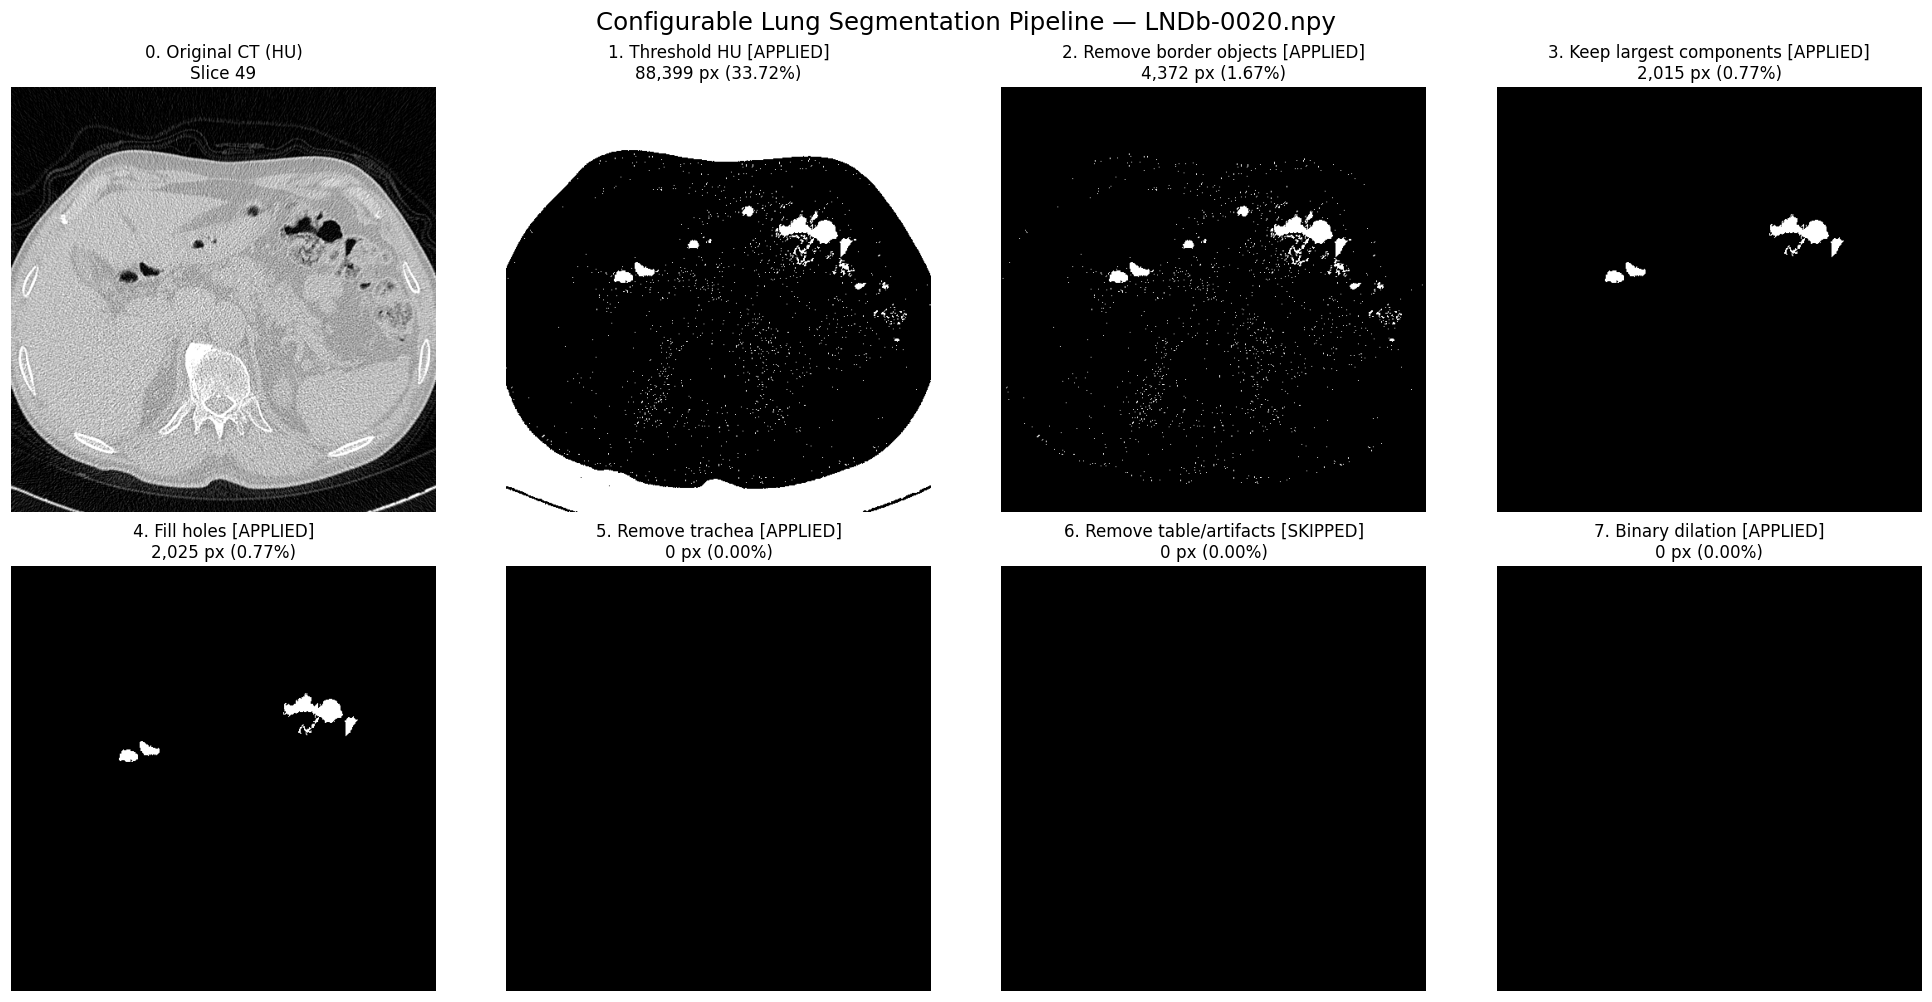

In [149]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
axes = axes.ravel()

axes[0].imshow(slice_image, cmap="gray", vmin=CT_WINDOW[0], vmax=CT_WINDOW[1])
axes[0].set_title(f"0. Original CT (HU)\nSlice {SLICE_INDEX}")

for axis, (stage_name, stage_mask) in zip(axes[1:], stage_results.items()):
    foreground = int(stage_mask.sum())
    percentage = 100 * foreground / stage_mask.size
    axis.imshow(stage_mask, cmap="gray", vmin=0, vmax=1)
    status = stage_status[stage_name]
    axis.set_title(
        f"{stage_name} [{status}]\n{foreground:,} px ({percentage:.2f}%)"
    )

for axis in axes:
    axis.axis("off")

fig.suptitle(
    f"Configurable Lung Segmentation Pipeline — {INPUT_PATH.name}",
    fontsize=16,
)
plt.show()

## 7. Compare the Experimental Pipeline with the Baseline

The baseline applies all seven stages. The experimental result follows `STAGE_ENABLED`. Red pixels exist only in the baseline, while green pixels exist only in the experimental result.

Baseline pixels       : 0
Experimental pixels   : 0
Baseline-only pixels  : 0
Experiment-only pixels: 0
Dice similarity       : 1.0000


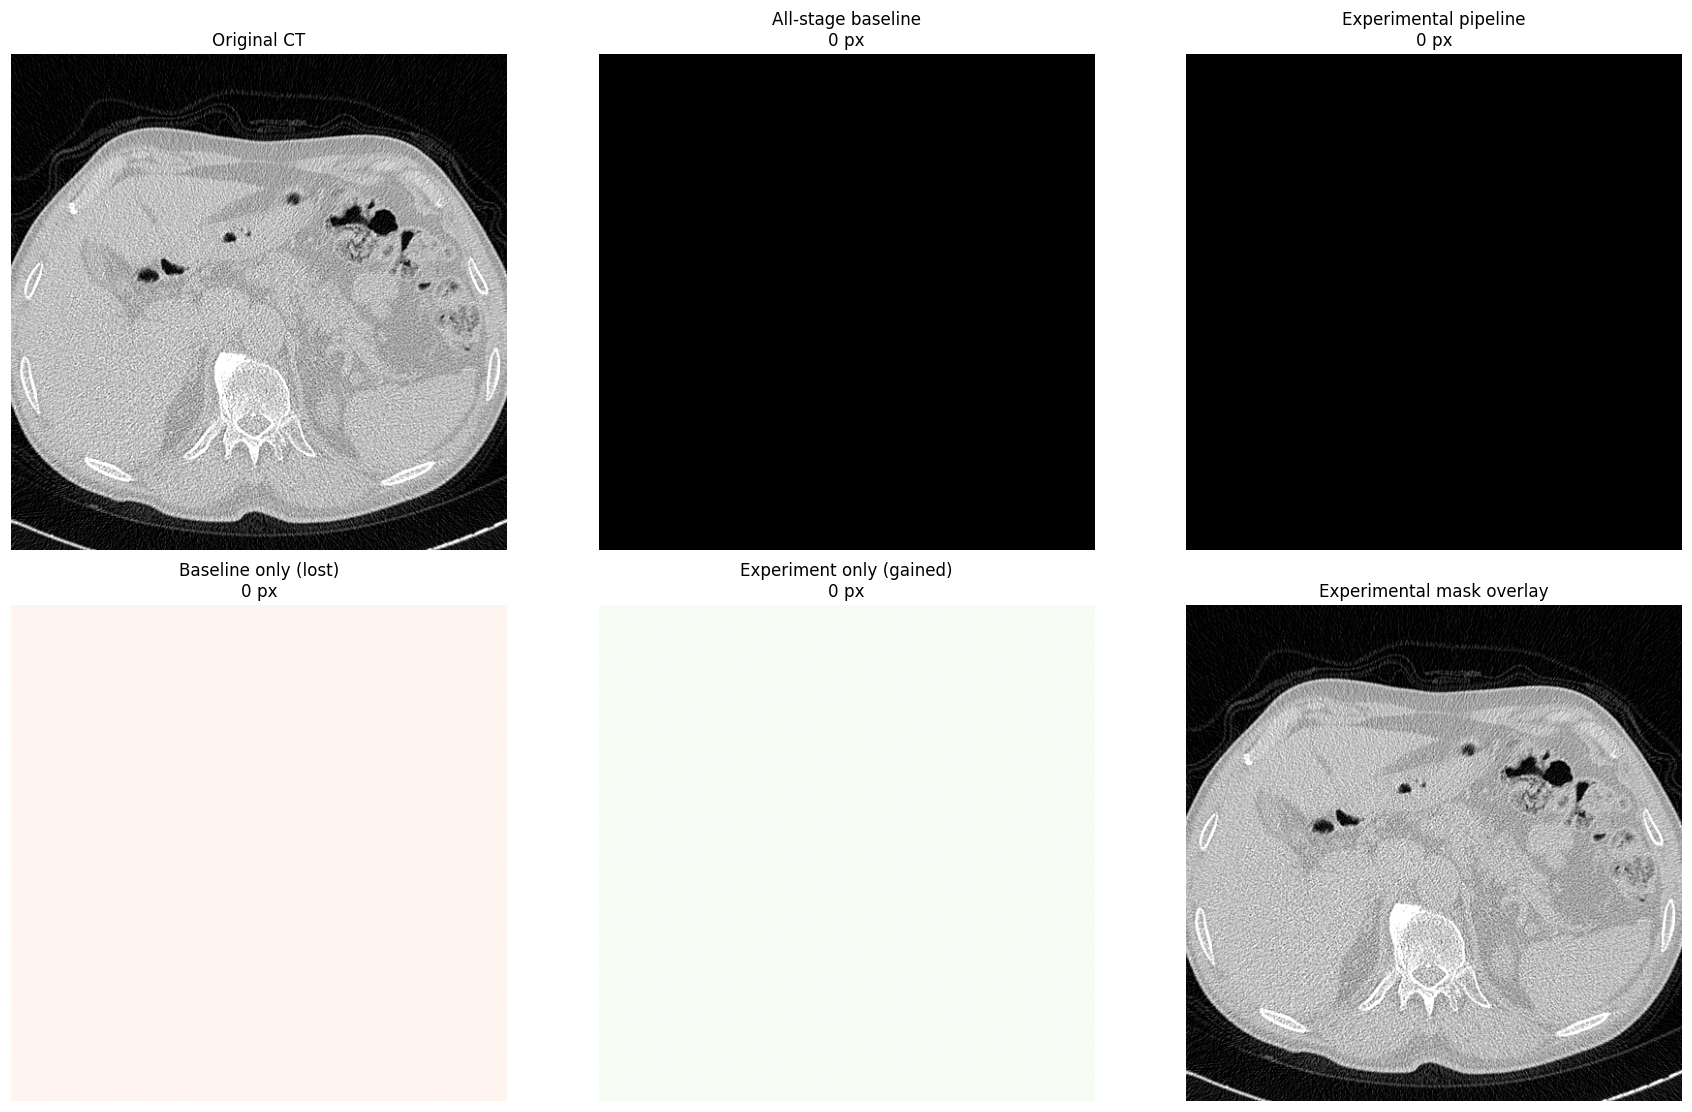

In [150]:
baseline_slice_mask = baseline_stage_results["7. Binary dilation"].astype(bool)
experimental_slice_mask = stage_results["7. Binary dilation"].astype(bool)
baseline_only = baseline_slice_mask & ~experimental_slice_mask
experiment_only = experimental_slice_mask & ~baseline_slice_mask
intersection = baseline_slice_mask & experimental_slice_mask
denominator = baseline_slice_mask.sum() + experimental_slice_mask.sum()
dice_score = 1.0 if denominator == 0 else 2 * intersection.sum() / denominator

print(f"Baseline pixels       : {baseline_slice_mask.sum():,}")
print(f"Experimental pixels   : {experimental_slice_mask.sum():,}")
print(f"Baseline-only pixels  : {baseline_only.sum():,}")
print(f"Experiment-only pixels: {experiment_only.sum():,}")
print(f"Dice similarity       : {dice_score:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

axes[0].imshow(slice_image, cmap="gray", vmin=CT_WINDOW[0], vmax=CT_WINDOW[1])
axes[0].set_title("Original CT")
axes[1].imshow(baseline_slice_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"All-stage baseline\n{baseline_slice_mask.sum():,} px")
axes[2].imshow(experimental_slice_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Experimental pipeline\n{experimental_slice_mask.sum():,} px")
axes[3].imshow(baseline_only, cmap="Reds", vmin=0, vmax=1)
axes[3].set_title(f"Baseline only (lost)\n{baseline_only.sum():,} px")
axes[4].imshow(experiment_only, cmap="Greens", vmin=0, vmax=1)
axes[4].set_title(f"Experiment only (gained)\n{experiment_only.sum():,} px")
axes[5].imshow(slice_image, cmap="gray", vmin=CT_WINDOW[0], vmax=CT_WINDOW[1])
axes[5].imshow(
    np.ma.masked_where(experimental_slice_mask == 0, experimental_slice_mask),
    cmap="Reds", alpha=0.30, vmin=0, vmax=1,
)
axes[5].set_title("Experimental mask overlay")

for axis in axes:
    axis.axis("off")
plt.show()

## 8. Segment the Entire CT Volume

Each axial slice is processed independently using the experimental `STAGE_ENABLED` configuration, and all masks are then stacked into a 3D volume.

In [151]:
def segment_lung_parenchyma(
    ct_volume: np.ndarray,
    stage_config: OrderedDict,
    initial_mask_volume: np.ndarray | None = None,
) -> np.ndarray:
    """Segment all slices with the selected stages and return a 3D mask."""
    masks = []
    for index, slice_image in enumerate(
        tqdm(ct_volume, desc="Segmenting volume", unit="slice")
    ):
        initial_mask = (
            None
            if initial_mask_volume is None
            else initial_mask_volume[index]
        )
        masks.append(process_slice(slice_image, stage_config, initial_mask))
    return np.stack(masks, axis=0).astype(np.uint8)


lung_mask_volume = segment_lung_parenchyma(
    ct_volume, STAGE_ENABLED, INITIAL_MASK_VOLUME
)
print(f"Shape mask       : {lung_mask_volume.shape}")
print(f"Data type        : {lung_mask_volume.dtype}")
print(f"Unique values    : {np.unique(lung_mask_volume)}")
print(f"Foreground voxel : {lung_mask_volume.sum():,}")
print(f"Mask proportion  : {lung_mask_volume.mean():.2%}")

Segmenting volume: 100%|██████████| 306/306 [00:08<00:00, 35.78slice/s]


Shape mask       : (306, 512, 512)
Data type        : uint8
Unique values    : [0 1]
Foreground voxel : 11,302,828
Mask proportion  : 14.09%


## 9. Quality Control Across Multiple Slices

The following montage checks mask consistency from the superior to the inferior lung regions.

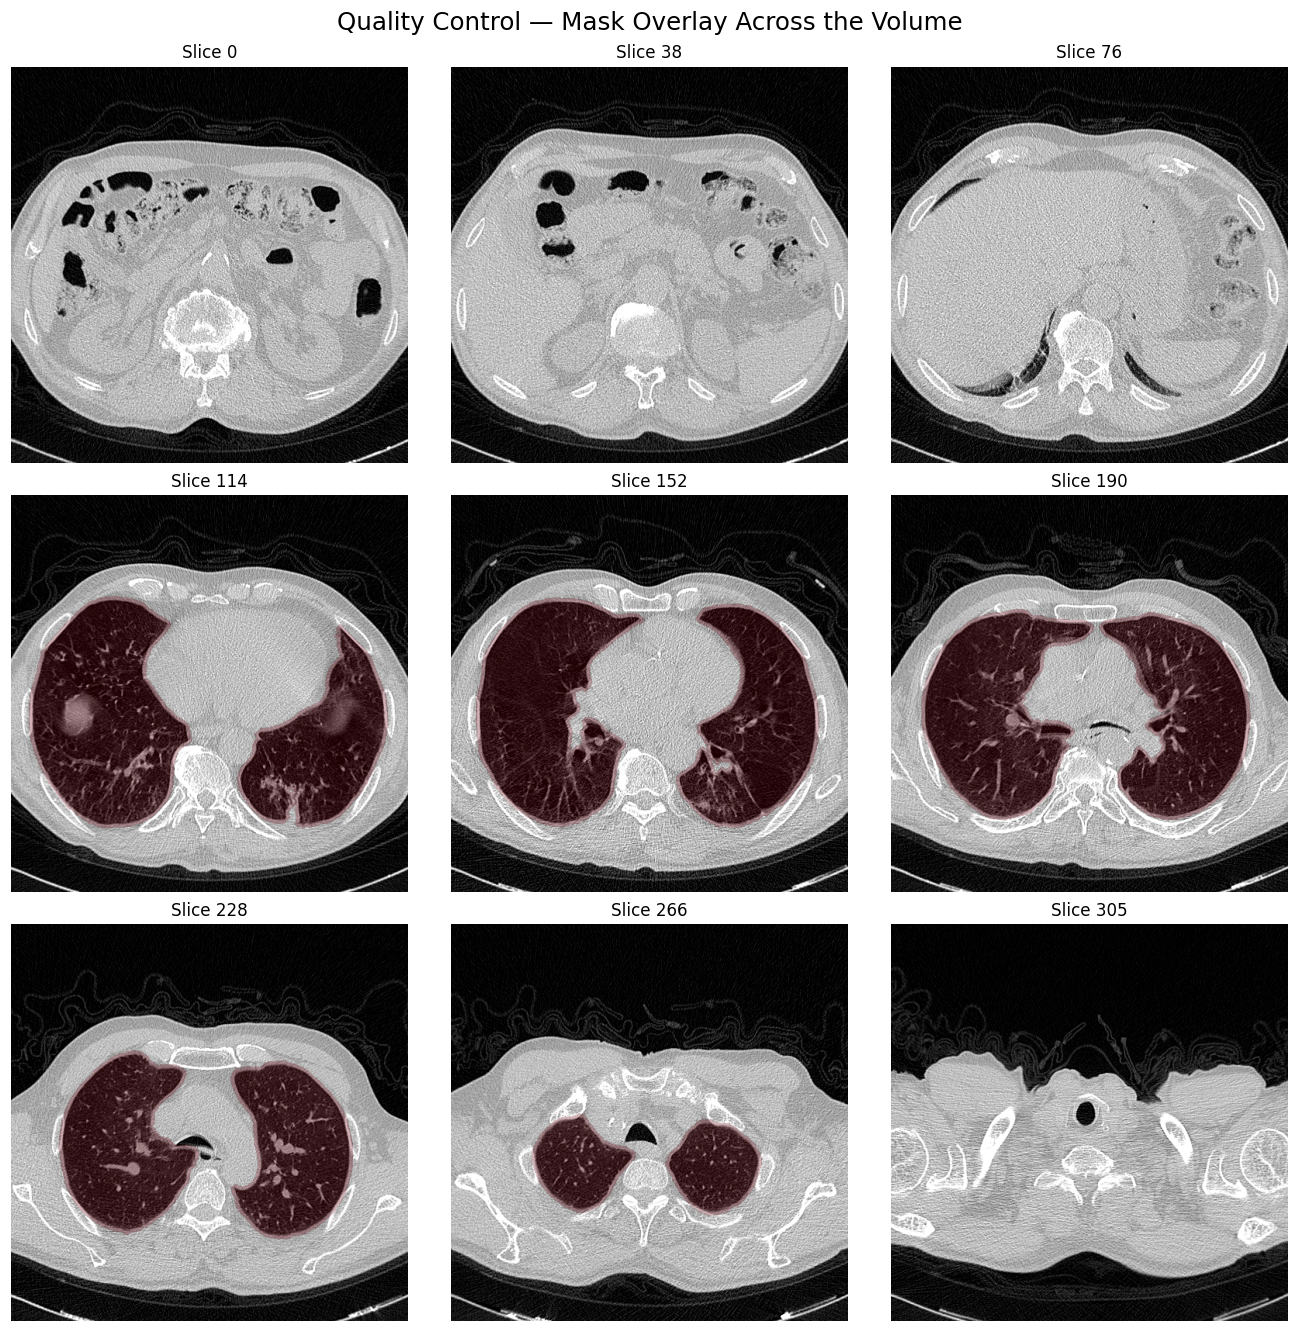

In [152]:
qc_indices = np.linspace(0, len(ct_volume) - 1, 9, dtype=int)
fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

for axis, index in zip(axes.ravel(), qc_indices):
    axis.imshow(
        ct_volume[index], cmap="gray",
        vmin=CT_WINDOW[0], vmax=CT_WINDOW[1],
    )
    axis.imshow(
        np.ma.masked_where(lung_mask_volume[index] == 0, lung_mask_volume[index]),
        cmap="Reds", alpha=0.30, vmin=0, vmax=1,
    )
    axis.set_title(f"Slice {index}")
    axis.axis("off")

fig.suptitle("Quality Control — Mask Overlay Across the Volume", fontsize=16)
plt.show()

## 10. Save the 3D Mask

Set `SAVE_MASK` to `True` to save the result. The output filename and directory match the original preprocessing pipeline.

In [153]:
SAVE_MASK = False
OUTPUT_DIR = PROJECT_ROOT / "000_dataset" / "_lidc" / "003_mask_parenchyma_npy"
OUTPUT_PATH = OUTPUT_DIR / INPUT_PATH.name

if SAVE_MASK:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    np.save(OUTPUT_PATH, lung_mask_volume.astype(np.uint8))
    print(f"Mask saved to: {OUTPUT_PATH}")
else:
    print("The mask was not saved. Set SAVE_MASK = True and rerun this cell.")
    print(f"Target output: {OUTPUT_PATH}")

The mask was not saved. Set SAVE_MASK = True and rerun this cell.
Target output: /Users/adityanugroho-f/Documents/mask-guided-lung-nodule-xai/000_dataset/_lidc/003_mask_parenchyma_npy/LNDb-0020.npy
